In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'non-targeting')
print('\n')
slk.configs.show()
slk.configs.reset_config()
slk.configs.get_config('ntc_label')

ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


ntc_label       = non-targeting
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


'NTC'

In [4]:
data = sc.read_h5ad("../../datasets/norman/Norman_2019.h5ad")
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(data, pert_key='perturbation_name', ntc_label='control', treatment_key=None, inplace=True)

AnnData object with n_obs × n_vars = 111255 × 19018
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804', 'guide_KIF18B', 'guide_KIF2C', '

In [5]:
slk.pp.treat_effect(
    data,
    label_col = 'pert',
    control_label = 'NTC',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

100%|██████████| 236/236 [00:20<00:00, 11.73it/s]


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = slk.tl.run_single(data, batch_size=2056, shuffle=True, num_workers=0, device=device, combinatorial=True, validate_every=50)

Training VAE on cuda …


Epochs:  86%|████████▌ | 172/200 [58:00<09:26, 20.23s/it, ATE=0.8302, CE=0.5290, ELBO=18894.4015, R2_ntc=0.9598, R2_p=0.9015, acc=0.963, pi25=0.30, pi99=0.94, tau=0.129]  


⏹ Early stopping at epoch 173 (best ELBO=18154.1978)


In [8]:
slk.tl.save_results(results, '../results/normal_model_bckp.pth')

In [13]:
model = slk.tl.load_results('../results/normal_model.pth')

In [16]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

In [17]:
data.uns['results']

{'acc': 0.008459062315523624,
 'rho_corr': array([[1.0000001 , 0.4796612 , 0.55062664, ..., 0.5644721 , 0.47932306,
         0.17439917],
        [0.4796612 , 1.        , 0.3595477 , ..., 0.46964127, 0.2970061 ,
         0.43774983],
        [0.55062664, 0.3595477 , 1.        , ..., 0.28126422, 0.8188912 ,
         0.55223185],
        ...,
        [0.5644721 , 0.46964127, 0.28126422, ..., 1.        , 0.38077444,
         0.19368745],
        [0.47932306, 0.2970061 , 0.8188912 , ..., 0.38077444, 1.0000001 ,
         0.5140416 ],
        [0.17439917, 0.43774983, 0.55223185, ..., 0.19368745, 0.5140416 ,
         0.99999994]], shape=(106, 106), dtype=float32),
 'z_corr': array([[ 0.9999999 ,  0.8578007 ,  0.6857553 , ...,  0.5457343 ,
          0.21613516, -0.22748226],
        [ 0.8578007 ,  1.        ,  0.6770129 , ...,  0.48723823,
          0.19550844, -0.47477588],
        [ 0.6857554 ,  0.6770129 ,  1.        , ...,  0.4104656 ,
          0.3544576 , -0.241893  ],
        ...,
     

In [18]:
slk.pl.plot_r2(data)

AttributeError: 'SparseCSRMatrixView' object has no attribute 'flatten'

In [19]:
slk.pl.plot_ev(data, cmax=2, top_n=50)

ValueError: Shape of passed values is (106, 50), indices imply (236, 50)

In [ ]:
# Useful dataframe that plot_ev_sig uses internally
slk.pl.make_ev_long_df(data, cond_idx=0, uns_key="results")

,pert,gene,ev,pval,qval
0,AAR2,NOC2L,2.042786e-04,4.740327e-01,7.734387e-01
1,AAR2,ISG15,2.188311e-03,6.661338e-16,3.758898e-14
2,AAR2,AURKAIP1,2.555210e-04,3.937090e-01,7.734387e-01
3,AAR2,ATAD3A,2.023823e-07,7.731957e-01,7.734387e-01
4,AAR2,RPL22,1.082816e-05,7.602170e-01,7.734387e-01
...,...,...,...,...,...
806980,ZNHIT6,MT-ND4L,5.770679e-03,2.205528e-01,6.343570e-01
806981,ZNHIT6,MT-ND4,8.391931e-02,1.000000e-300,1.519231e-299
806982,ZNHIT6,MT-ND5,1.646628e-03,6.187894e-01,7.674800e-01
806983,ZNHIT6,MT-ND6,1.307096e-02,3.803099e-03,2.220036e-02


In [11]:
slk.pl.plot_ev_sig(
    data,
    cond_idx=0,
    uns_key="results",
    alpha=0.05,
    top_n_genes=10,
    min_sig_genes=3,
    cluster_rows=True,
    cluster_cols=False,
    use_clustermap=True,
)

KeyError: 'results'

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


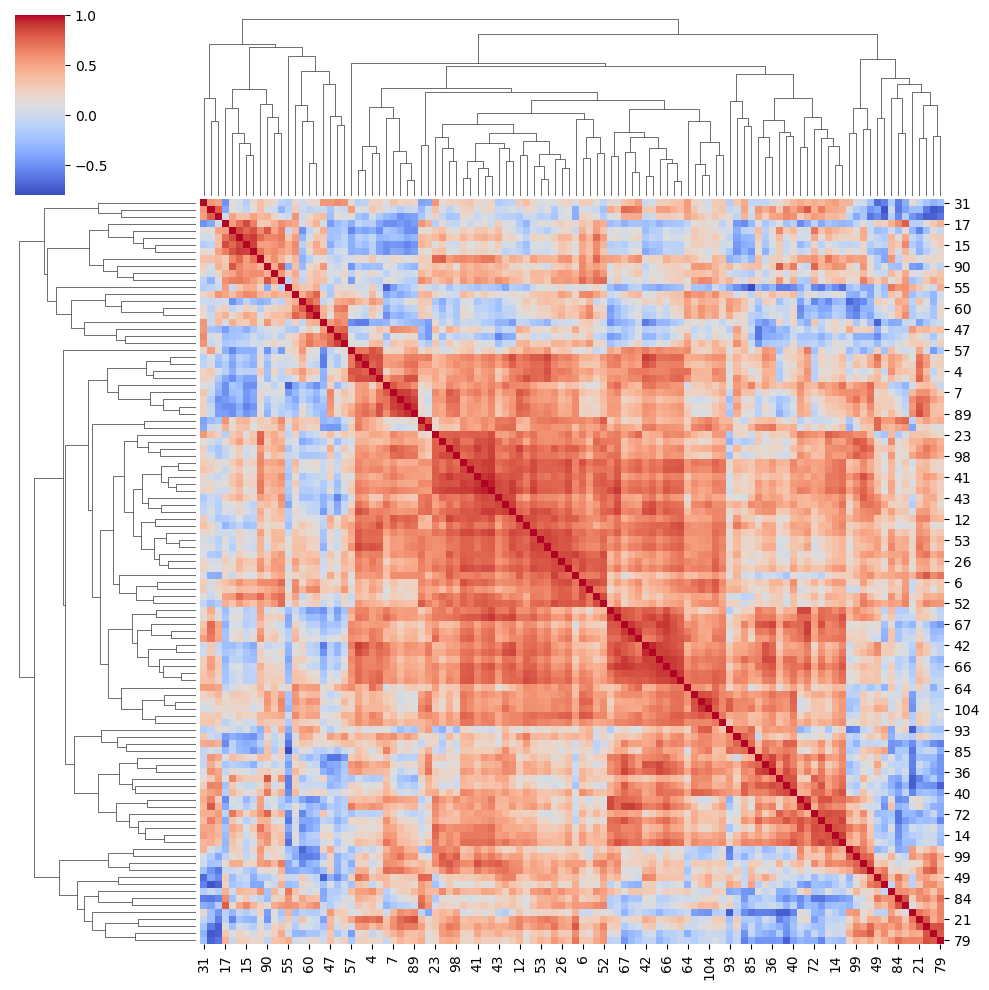

In [20]:
slk.pl.plot_corr(data)

In [77]:
sub.obs.perturbation_name

index
AAACCTGAGGCATGTG-1          TSC22D1
AAACCTGAGGCCCTTG-1      KLF1+MAP2K6
AAACCTGCAGACGTAG-1    CEBPE+RUNX1T1
AAACCTGCAGCCTTGG-1            MAML2
AAACCTGCATCTCCCA-1            CEBPE
                          ...      
TTTGTCATCAGTACGT-8            FOXA3
TTTGTCATCCACTCCA-8            CELF2
TTTGTCATCCCAACGG-8           BCORL1
TTTGTCATCCTCCTAG-8    PTPN12+ZBTB10
TTTGTCATCTGGCGAC-8           MAP4K3
Name: perturbation_name, Length: 99420, dtype: category
Categories (236, object): ['AHR', 'AHR+FEV', 'AHR+KLF1', 'ARID1A', ..., 'ZBTB10', 'ZBTB25', 'ZC3HAV1', 'ZNF318']

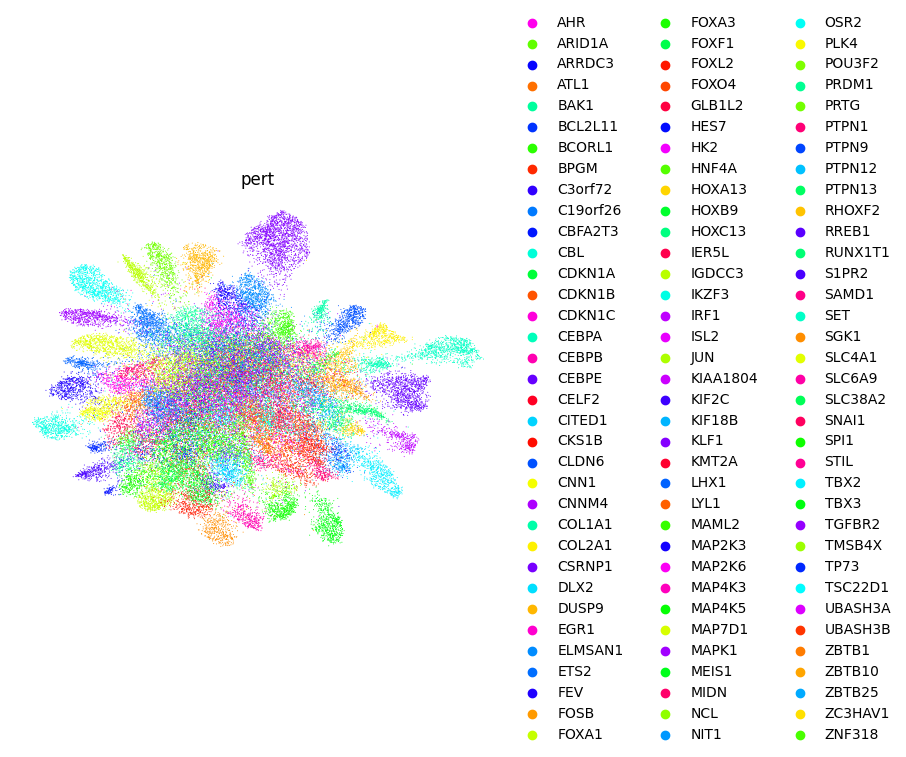

In [78]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[(data.obs[p_key] != NTC) & (~data.obs["perturbation_name"].astype(str).str.contains(r"\+"))]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

In [26]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = -0.000  (p = 9.7e-01)
 Pearson  r = 0.003  (p = 8.4e-01)


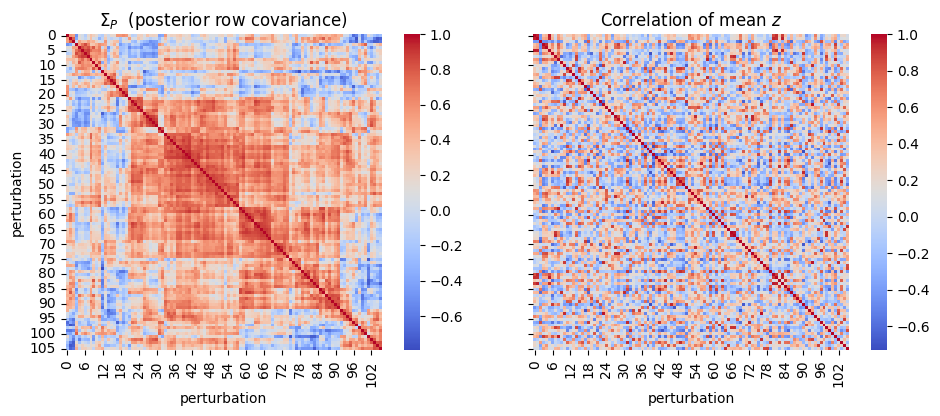

In [23]:
slk.pl.plot_zcorr(data)

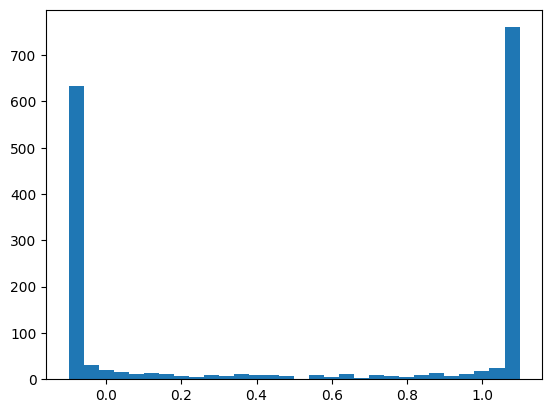

In [27]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

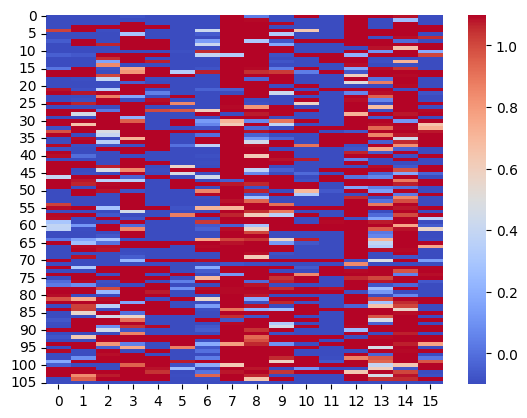

In [28]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

In [34]:
dataset = slk.tl.PerturbMatchingDataset(data, combinatorial=True)
all_genes = dataset.perturbation_dict.keys()

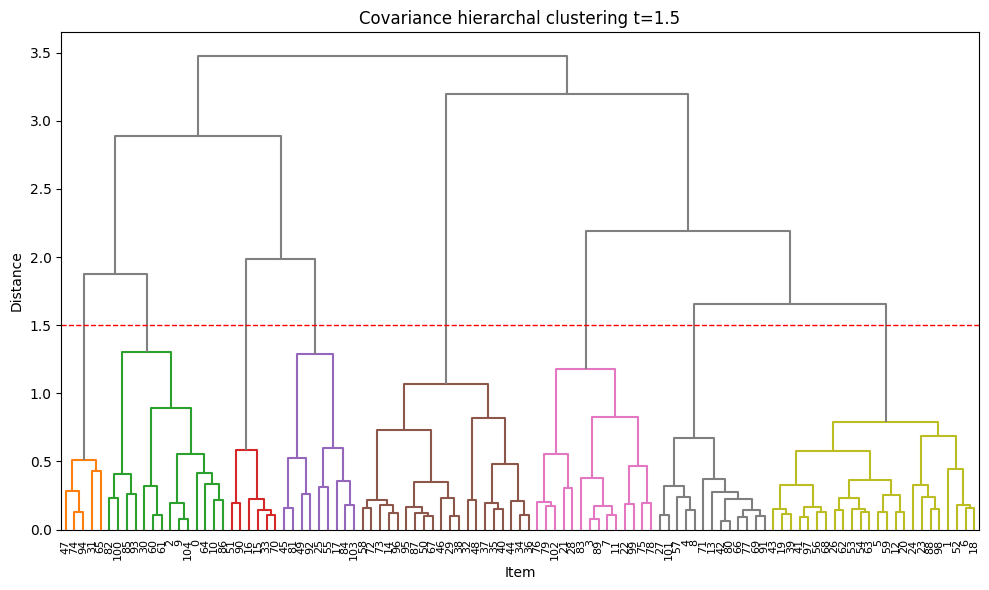

In [ ]:
C = data.uns['results']['rho_corr']
cov_subset = C[:-1, :-1] #TODO change back, working around a fixed bug

groups = slk.tl.cluster_rho(data, t=1.5, show=True, rho_corr=cov_subset)

In [68]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)
named_groups

,group
AHR,2
ARID1A,8
ARRDC3,2
ATL1,6
BAK1,7
...,...
ZBTB1,2
ZBTB10,7
ZBTB25,6
ZC3HAV1,4


pert_group
1    3905
2    8497
3    3455
4    7557
5    9999
6    8205
7    6359
8    9758
Name: count, dtype: int64


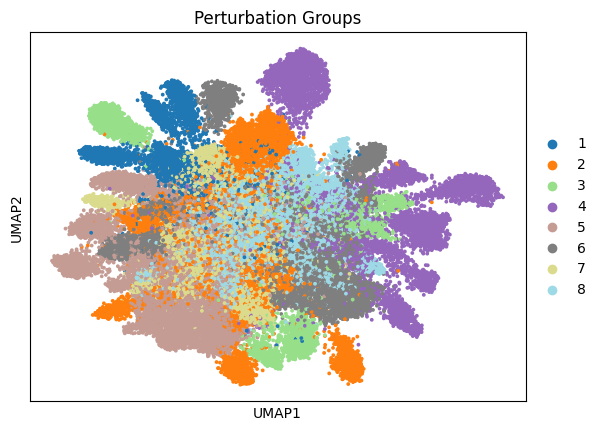

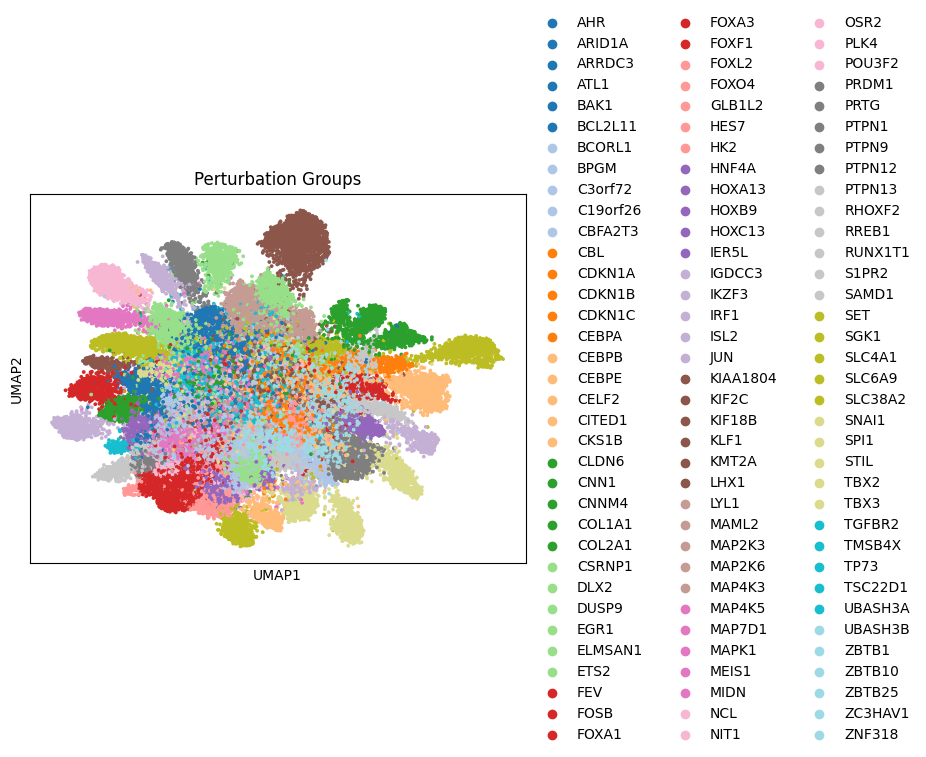

In [80]:
# map perturbation -> group using named_groups (index=gene, column='group')
gene_to_group = named_groups['group'].to_dict()

# assign group to obs based on slk pert key
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group)

# mark NTC / unknown perturbations as -1 and ensure integer dtype
sub.obs['pert_group'] = sub.obs['pert_group'].fillna(-1).astype('category')

# quick summary
print(sub.obs['pert_group'].value_counts().sort_index())

sc.pl.umap(sub, color=['pert_group'], title='Perturbation Groups', palette='tab20', size=30)
sc.pl.umap(sub, color=['perturbation_name'], title='Perturbation Groups', palette='tab20', size=30)